Notebook

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [2]:
# Load Rock-Paper-Scissors dataset
dataset_name = "rock_paper_scissors"
(train_ds, val_ds), ds_info = tfds.load(dataset_name, split=['train', 'test'], as_supervised=True, with_info=True)
print(f"Dataset loaded: {dataset_name}")
print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/2520 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.63WVOM_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...:   0%|          | 0/372 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.63WVOM_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
Dataset loaded: rock_paper_scissors
tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir=PosixGPath('/tmp/tmp63zklk44tfds'),
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moron

In [3]:
# Preprocess the data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE) / 255.0  # Normalize
    return image, label

train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [29]:
# Function to build and train models
def build_and_train_model(base_model, model_name, trainable_layers=0, num_epochs=5):
    base_model.trainable = False  # Freeze base model by default
    if trainable_layers > 0:
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(3, activation='softmax')(x)
    model = Model(inputs=base_model.input,
                  outputs=predictions)

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(train_ds, validation_data=val_ds, epochs=num_epochs)

    # Plot training history
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()
    plt.show()

    # Make predictions on validation set
    predictions = model.predict(val_ds)
    predicted_labels = tf.argmax(predictions, axis=1)

    # # Print some predictions
    # print("Sample Predictions:")
    # for i in range(5):  # Print predictions for the first 5 images
    #     print(f"Image {i + 1}: Predicted Label: {predicted_labels[i].numpy()}, True Label: {val_ds.unbatch().element_spec[1].dtype.as_numpy_dtype(val_ds.unbatch().as_numpy_iterator().__next__()[1])}")

    # Display images with predictions
    print("Sample Predictions:")
    indices = [1, 50, 100, 150, 200, 250]  # Define the desired indices
    for i in indices:  # Display predictions for specified indices
        image, true_label = next(iter(val_ds.unbatch().skip(i - 1).take(1).as_numpy_iterator()))
        plt.imshow(image)
        plt.title(f"Predicted: {predicted_labels[i-1].numpy()}, True: {true_label}")
        plt.show()

    return history

In [ ]:
# Using MobileNetV2, ResNet50, and EfficientNetB0
base_models = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "ResNet50": ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    "EfficientNetB0": EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
}

results = {}
for model_name, base_model in base_models.items():
    print(f"Training {model_name} with frozen layers")
    results[model_name] = build_and_train_model(base_model, model_name)

    print(f"Training {model_name} with trainable layers")
    results[model_name + "_trainable"] = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=5)

print("Training complete!")


Training MobileNetV2 with frozen layers
Epoch 1/5


In [5]:
results

{'MobileNetV2': <keras.src.callbacks.history.History at 0x7bb833e70190>,
 'MobileNetV2_trainable': <keras.src.callbacks.history.History at 0x7bb7ceda3590>,
 'ResNet50': <keras.src.callbacks.history.History at 0x7bb7af582510>,
 'ResNet50_trainable': <keras.src.callbacks.history.History at 0x7bb79a563e50>,
 'EfficientNetB0': <keras.src.callbacks.history.History at 0x7bb79a2e6a50>,
 'EfficientNetB0_trainable': <keras.src.callbacks.history.History at 0x7bb78bcc3310>}

In [12]:
model_name = "MobileNetV2"
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),

results2 = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=50)

AttributeError: 'tuple' object has no attribute 'trainable'

In [22]:
# Using MobileNetV2, ResNet50, and EfficientNetB0
base_models = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
}

results_2 = {}
for model_name, base_model in base_models.items():
    # print(f"Training {model_name} with frozen layers")
    # results[model_name] = build_and_train_model(base_model, model_name)

    print(f"Training {model_name} with trainable layers")
    results_2[model_name + "_trainable"] = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=50)

print("Training complete!")


Training MobileNetV2 with trainable layers
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - accuracy: 0.8877 - loss: 0.2973 - val_accuracy: 0.6828 - val_loss: 1.3900
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9986 - loss: 0.0061 - val_accuracy: 0.6774 - val_loss: 1.6059
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.6882 - val_loss: 1.5374
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.6962 - val_loss: 1.5218
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 1.0000 - loss: 7.0151e-04 - val_accuracy: 0.7097 - val_loss: 1.4679
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 1.0000 - loss: 6.6438e-04 - val_accuracy: 0.7124 - val_loss: 1.3759
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 1.0000 - loss: 3.5068e-04 - val_accuracy: 0.7258 - val_loss: 1.2766
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - a

KeyboardInterrupt: 

Training MobileNetV2 with trainable layers
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 159ms/step - accuracy: 0.8684 - loss: 0.3328 - val_accuracy: 0.6667 - val_loss: 1.5730


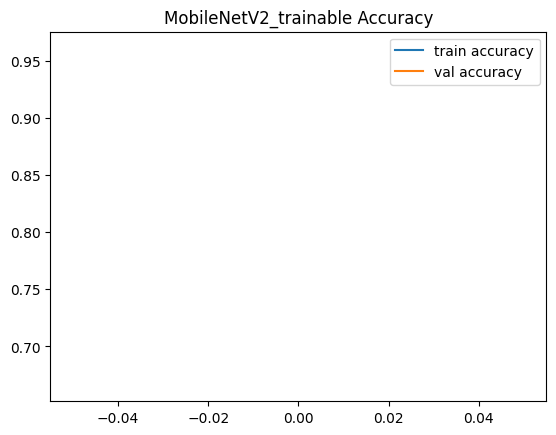

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 284ms/step
Sample Predictions:


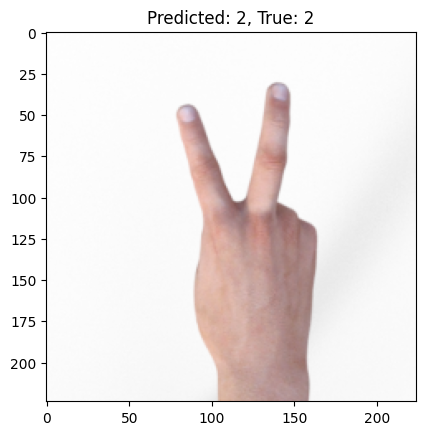

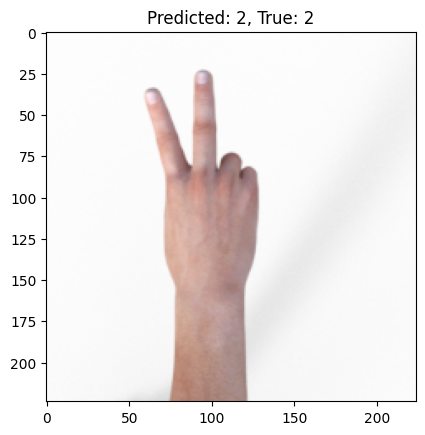

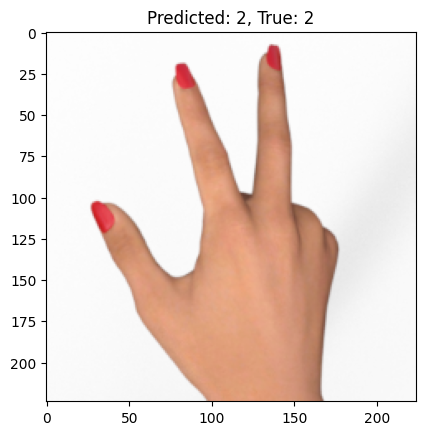

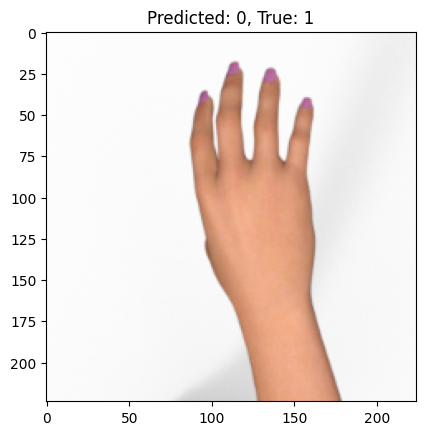

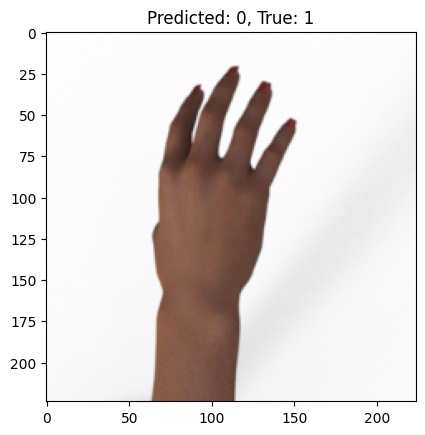

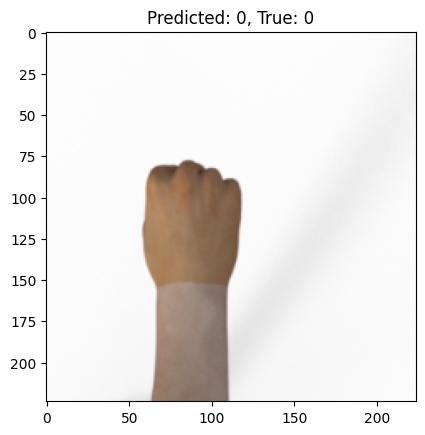

Training complete!


In [28]:
# Using MobileNetV2, ResNet50, and EfficientNetB0
base_models = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
}

results_2 = {}
for model_name, base_model in base_models.items():
    # print(f"Training {model_name} with frozen layers")
    # results[model_name] = build_and_train_model(base_model, model_name)

    print(f"Training {model_name} with trainable layers")
    results_2[model_name + "_trainable"] = build_and_train_model(base_model, model_name + "_trainable", trainable_layers=20, num_epochs=1)

print("Training complete!")
